<a href="https://colab.research.google.com/github/surajjeoor/masai_assignments/blob/main/Decision_Trees_deep_dive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ── Standard library ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ───────────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score)
from sklearn.inspection import PartialDependenceDisplay

# ── Plotting style ─────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All imports successful!')
import sklearn; print(f'   Sklearn: {sklearn.__version__}')


All imports successful!
   Sklearn: 1.6.1


In [4]:
# ── Generate a realistic synthetic credit risk dataset ─────────────────────────
np.random.seed(42)
N = 2000

credit_score    = np.random.randint(300, 851, N)
income          = np.random.normal(65000, 20000, N).clip(20000, 200000)
loan_amount     = np.random.normal(15000, 7000, N).clip(1000, 60000)
age             = np.random.randint(21, 65, N)
months_employed = np.random.randint(0, 300, N)
num_credit_lines= np.random.randint(1, 10, N)
interest_rate   = np.random.uniform(5, 25, N).round(2)
num_loans       = np.random.randint(0, 5, N)
has_mortgage    = np.random.randint(0, 2, N)
has_dependents  = np.random.randint(0, 2, N)
has_cosigner    = np.random.randint(0, 2, N)
loan_purpose    = np.random.choice(['education','home','business','auto','personal'], N)
loan_to_income  = (loan_amount / income).round(4)

# Default probability driven by realistic factors
log_odds = (
    -4.0
    - 0.006 * credit_score
    + 2.5   * loan_to_income
    + 0.03  * interest_rate
    - 0.003 * months_employed
    + 0.3   * num_loans
    - 0.5   * has_cosigner
    + 0.2   * has_dependents
)
prob_default = 1 / (1 + np.exp(-log_odds))
default = (np.random.rand(N) < prob_default).astype(int)

df = pd.DataFrame({
    'age': age, 'income': income.round(0), 'loan_amount': loan_amount.round(0),
    'loan_to_income': loan_to_income, 'credit_score': credit_score,
    'months_employed': months_employed, 'num_credit_lines': num_credit_lines,
    'interest_rate': interest_rate, 'num_loans': num_loans,
    'has_mortgage': has_mortgage, 'has_dependents': has_dependents,
    'loan_purpose': loan_purpose, 'has_cosigner': has_cosigner,
    'default': default
})

print('Dataset shape:', df.shape)
print('Default rate: {:.1f}%'.format(df['default'].mean() * 100))
df.head()


Dataset shape: (2000, 14)
Default rate: 0.4%


,age,income,loan_amount,loan_to_income,credit_score,months_employed,num_credit_lines,interest_rate,num_loans,has_mortgage,has_dependents,loan_purpose,has_cosigner,default
0,48,90795.0,15132.0,0.1667,402,190,1,5.42,1,0,1,home,0,0
1,39,78464.0,6798.0,0.0866,735,169,1,17.57,2,0,1,business,1,0
2,44,62231.0,26870.0,0.4318,570,44,1,17.59,3,0,0,auto,0,0
3,39,40514.0,28281.0,0.6981,406,13,4,24.74,2,0,0,auto,0,0
4,33,60820.0,16097.0,0.2647,371,230,1,12.96,4,1,1,auto,1,0


#Histogram experimentation

I am doing some histogram experimentation to understand what histogram is.
there are lots of parameters in plt.hist function. what is the role of the parameters is the main agenda of below cell.


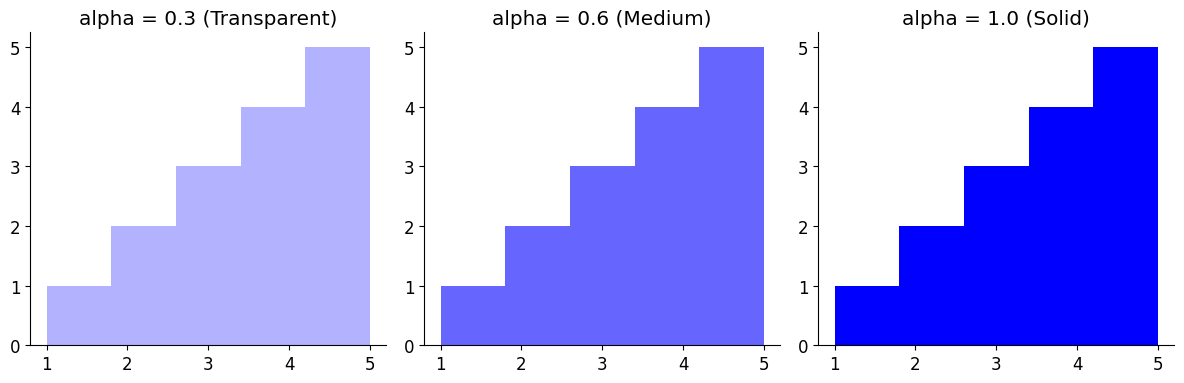

In [5]:
import matplotlib.pyplot as plt
import numpy as np

data = [1, 2, 2, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5]

# Different transparency levels
plt.figure(figsize=(12, 4))

# alpha = 0.3 (very transparent)
plt.subplot(1, 3, 1)
plt.hist(data, alpha=0.3, color='blue', bins=5)
plt.title('alpha = 0.3 (Transparent)')

# alpha = 0.6 (medium transparency)
plt.subplot(1, 3, 2)
plt.hist(data, alpha=0.6, color='blue', bins=5)
plt.title('alpha = 0.6 (Medium)')

# alpha = 1.0 (opaque/solid)
plt.subplot(1, 3, 3)
plt.hist(data, alpha=1.0, color='blue', bins=5)
plt.title('alpha = 1.0 (Solid)')

plt.tight_layout()
plt.show()

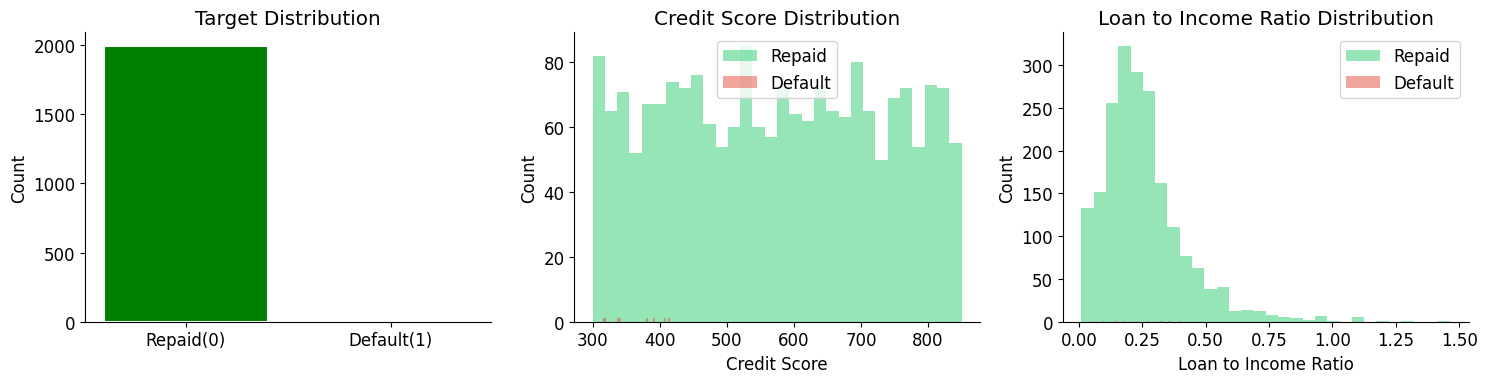

In [6]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
axes[0].bar(['Repaid(0)','Default(1)'],df['default'].value_counts().sort_index(),color=['green','red'],edgecolor='White', linewidth=1.5)
axes[0].set_title('Target Distribution')
axes[0].set_ylabel('Count')


for label, color in [(0,'#2ecc71'), (1,'#e74c3c')]:
  axes[1].hist(df[df['default']==label]['credit_score'],bins=30,alpha=0.5,color=color,label='default' if label else 'Repaid')
axes[1].legend(['Repaid','Default'])
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Credit Score Distribution')

for label, color in [(0,'#2ecc71'), (1,'#e74c3c')]:
  axes[2].hist(df[df['default']==label]['loan_to_income'],bins=30,alpha=0.5,color=color,label='default' if label else 'Repaid')
axes[2].legend(['Repaid','Default'])
axes[2].set_xlabel('Loan to Income Ratio')

axes[2].set_ylabel('Count')
axes[2].set_title('Loan to Income Ratio Distribution')

plt.tight_layout()
plt.show()

In [30]:
#Encode categorical features and prepare X and y
df_model=df.copy()
df_model=pd.get_dummies(df_model,columns=['loan_purpose'],drop_first=True)
y=df_model['default']
X=df_model.drop('default',axis=1)
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"Train set: {x_train.shape[0]} rows")
print(f"Test set: {x_test.shape[0]} rows")
print(f"Features: {x_train.shape[1]}")
FEATURES=x_train.columns.tolist()

Train set: 1600 rows
Test set: 400 rows
Features: 16


In [31]:
print(FEATURES)

['age', 'income', 'loan_amount', 'loan_to_income', 'credit_score', 'months_employed', 'num_credit_lines', 'interest_rate', 'num_loans', 'has_mortgage', 'has_dependents', 'has_cosigner', 'loan_purpose_business', 'loan_purpose_education', 'loan_purpose_home', 'loan_purpose_personal']


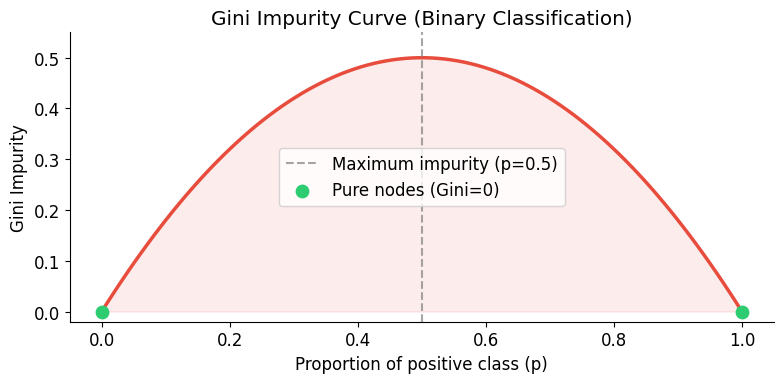

In [9]:
# As you know about the gini impurity it is the measure of how often the randomly chosen element turned about to be wrong
#Plotting the gini impurity
#write the function of jini impurity
def gini_impurity(p_positive):
  p_negative=1-p_positive
  return 1-(p_positive**2+p_negative**2)

p_values=np.linspace(0,1,100)
gini_values=[gini_impurity(p) for p in p_values]
plt.figure(figsize=(8, 4))
plt.plot(p_values, gini_values, color='#e74c3c', linewidth=2.5)
plt.fill_between(p_values, gini_values, alpha=0.1, color='#e74c3c')
plt.axvline(0.5, linestyle='--', color='gray', alpha=0.7, label='Maximum impurity (p=0.5)')
plt.scatter([0, 1], [0, 0], s=80, color='#2ecc71', zorder=5, label='Pure nodes (Gini=0)')
plt.xlabel('Proportion of positive class (p)')
plt.ylabel('Gini Impurity')
plt.title('Gini Impurity Curve (Binary Classification)')
plt.legend()
plt.ylim(-0.02, 0.55)
plt.tight_layout()
plt.show()


### Weighted Gini for a Split

When we split a node into two children, the **Gini of the split** is a weighted average:

$$\text{Gini}_{split} = \frac{N_L}{N} \cdot \text{Gini}(L) + \frac{N_R}{N} \cdot \text{Gini}(R)$$

The CART algorithm tries every possible feature and every possible threshold,
computes this weighted Gini for each candidate split, and **chooses the one that
gives the lowest weighted Gini** — i.e., the purest children.


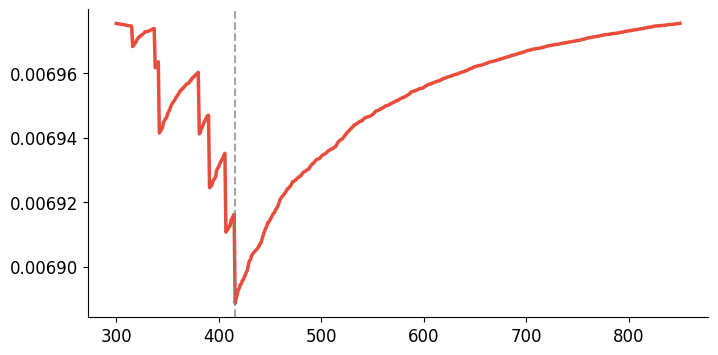

In [27]:
def weighted_gain(y_left, y_right):
  N_left=len(y_left)
  N_right=len(y_right)
  N=N_left+N_right
  def node_gini(y):
        if len(y) == 0: return 0
        p = y.mean()
        return 1 - p**2 - (1-p)**2
  return (len(y_left)/N)*node_gini(y_left) + (len(y_right)/N)*node_gini(y_right)


threshold=sorted(df['credit_score'].unique())
gini_scores=[]
for t in threshold:
  y_left=df[df['credit_score']<=t]['default']
  y_right=df[df['credit_score']>t]['default']
  weighted_gain_2=weighted_gain(y_left,y_right)
  gini_scores.append(weighted_gain_2)
plt.figure(figsize=(8, 4))
best_threshold=threshold[np.argmin(gini_scores)]
best_gini=min(gini_scores)
plt.plot(threshold,gini_scores,color='#e74c3c',linewidth=2.5)
plt.axvline(best_threshold,linestyle='--',color='gray',alpha=0.7,label=f'Best threshold: {best_threshold} (Gini={best_gini:.4f})')
plt.show()

In [23]:
print(min(gini_scores))

0.0068886363636363294


In [24]:
print(best_threshold)

416


In [28]:
#built an unconstrained decision tree----------------------------------
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

tr_dep=dt.get_depth()
num_leaves=dt.get_n_leaves()
trsin_acc=dt.score(x_train,y_train)
trtest_acc=dt.score(x_test,y_test)
print(f"Tree length: {tr_dep}")
print(f"Train accuracy: {trsin_acc:.4f}")
print(f"Test accuracy: {trtest_acc:.4f}")
print(f"Number of leaves:{num_leaves}")

Tree length: 7
Train accuracy: 1.0000
Test accuracy: 0.9900
Number of leaves:14


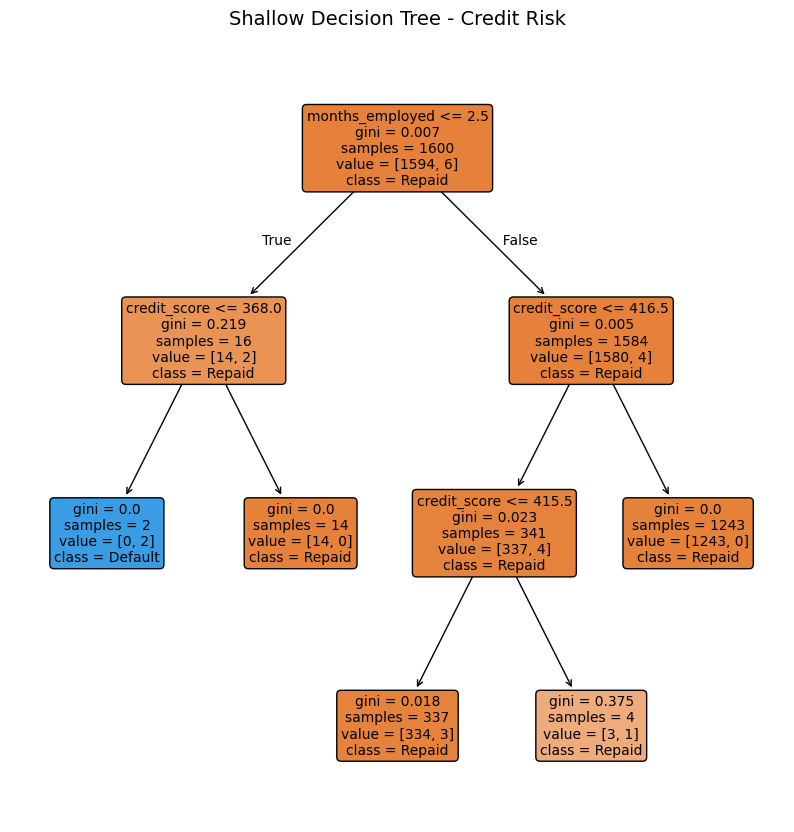

In [32]:
#building the shallow tree for the visualization
tree_viz=DecisionTreeClassifier(max_depth=3,random_state=42)
tree_viz.fit(x_train,y_train)
fig,ax=plt.subplots(figsize=(10,10))
plot_tree(
    tree_viz,
    feature_names=FEATURES,
    class_names=['Repaid', 'Default'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax,
    impurity=True,
    proportion=False
)
plt.title('Shallow Decision Tree - Credit Risk', fontsize=14, pad=20)
plt.show()